In [1]:
#!pip install statsmodels
#!pip install tensorflow
#!pip install torch torchvision

In [2]:
# Data manipulatie
import pandas as pd
import statsmodels.api as sm

# Machine Learning
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, roc_auc_score, classification_report
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# Neurale Netwerken
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from transformers import BertTokenizer, BertForSequenceClassification

# Visualisatie
import matplotlib.pyplot as plt
import seaborn as sns

# Vaste seed voor reproduceerbaarheid
seed = 6

### Voorbereiden data

In [3]:
df_train = pd.read_csv('../zorgdata/df_train.csv', index_col=False)
df_valid = pd.read_csv('../zorgdata/df_valid.csv', index_col=False)

In [4]:
# Selecteer variabelen om mee te nemen in de modellen
excluded = ['ct_id', 'datum', 'rapportage', 'onrustscore', 'rapportage_clean', 
            'rapportage_len_chars', 'rapportage_clean_len_chars', 'rapportage_clean_len_words', 'discipline']

label = 'onrust'

X_train = df_train.drop(excluded + [label], axis=1)
y_train = df_train[label]

X_valid = df_valid.drop(excluded + [label], axis=1)
y_valid = df_valid[label]

X_train_c = X_train.assign(const=1)

### Logistische regressie

In [5]:
# Train het logistische regressiemodel
lr_model = sm.Logit(y_train, X_train_c)
result = lr_model.fit()

# Bereken de initiële AIC
initial_aic = result.aic

# Herhaal backward elimination totdat de AIC niet meer verbetert
while True:
    max_p_value = result.pvalues.max()

    if max_p_value > 0.05:
        variable_to_remove = result.pvalues.idxmax()
        X_train_c = X_train_c.drop(variable_to_remove, axis=1)
        
        # Gebruik sm.Logit consistent
        lr_model = sm.Logit(y_train, X_train_c)
        result = lr_model.fit()
        
        # Bereken de nieuwe AIC
        new_aic = result.aic
        
        # Stop als de AIC niet meer verbetert
        if new_aic >= initial_aic:
            break
        else:
            initial_aic = new_aic
    else:
        # Als alle p-waarden onder de drempelwaarde liggen, stop dan de eliminatie
        break

# Bekijk de uiteindelijke samenvatting van het model
print(result.summary2())

         Current function value: 0.241033
         Iterations: 35


/Users/eva/anaconda3/envs/nlp_env/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Optimization terminated successfully.
         Current function value: 0.241033
         Iterations 9
Optimization terminated successfully.
         Current function value: 0.241033
         Iterations 9
Optimization terminated successfully.
         Current function value: 0.241034
         Iterations 9
Optimization terminated successfully.
         Current function value: 0.241037
         Iterations 9
Optimization terminated successfully.
         Current function value: 0.241040
         Iterations 9
Optimization terminated successfully.
         Current function value: 0.241047
         Iterations 9
Optimization terminated successfully.
         Current function value: 0.241082
         Iterations 9
Optimization terminated successfully.
         Current function value: 0.241102
         Iterations 9
Optimization terminated successfully.
         Current function value: 0.241131
         Iterations 9
Optimization terminated successfully.
         Current function value: 0.241176
  

In [6]:
# Geselecteerde variabelen na backward elimination
selected_variables = X_train_c.columns.tolist()
X_valid_c = df_valid.assign(const=1)[selected_variables]

In [7]:
# Voorspellingen maken op de validatie dataset

# Maak een nieuwe df met de voorspellingen
df_valid_pred = df_valid[['onrustscore', 'onrust', 'rapportage']].copy()

# En voeg de voorspellingen toe
df_valid_pred['pred_lr_prob'] = result.predict(X_valid_c)
df_valid_pred['pred_lr'] = (df_valid_pred['pred_lr_prob'] >= 0.5).astype(int)

### Random forest

In [8]:
# # Hyperparameters die je wilt testen
# param_grid = {
#     'n_estimators': [100, 501],
#     'max_depth': [None, 10, 30],
#     'min_samples_split': [2, 10],
#     'min_samples_leaf': [1, 4]
# }

# # Initialiseren van de Grid Search met cross-validation
# grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=seed), 
#                            param_grid=param_grid, 
#                            cv=5, # Aantal folds voor crossvalidaion
#                            n_jobs=-1, # Gebruik alle beschikbare CPU-cores
#                            verbose=2, # Toon gedetailleerde voortgangsinformatie
#                            scoring='roc_auc') # AUC als prestatie-indicator

# # Voer de grid search uit met trainingsdata
# grid_search.fit(X_train, y_train)

# # Beste parameters en bijbehorende AUC-score
# print("Beste hyperparameters:", grid_search.best_params_)
# print("Beste AUC-score:", grid_search.best_score_)

# # Beste model
# best_rf_model = grid_search.best_estimator_

In [9]:
# Random Forest Model
rf_model = RandomForestClassifier(n_estimators=501, random_state=seed, max_depth=None, min_samples_leaf=4, min_samples_split=2)

# Trainen van het model met trainingsdata
rf_model.fit(X_train, y_train)

RandomForestClassifier(min_samples_leaf=4, n_estimators=501, random_state=6)

In [10]:
# Voorspellingen maken op de validatieset
df_valid_pred['pred_rf'] = rf_model.predict(X_valid)
df_valid_pred['pred_rf_prob'] = rf_model.predict_proba(X_valid)[:, 1]

In [11]:
# Variable importance 
feature_importances = pd.DataFrame(rf_model.feature_importances_,
                                   index = X_train.columns,
                                   columns=['importance']).sort_values('importance', ascending=False)
print(feature_importances[0:10])

              importance
topic_2         0.114875
embedding_4     0.086122
embedding_38    0.064477
embedding_15    0.062182
embedding_13    0.044758
embedding_42    0.038749
embedding_43    0.037445
embedding_18    0.036688
embedding_0     0.034463
embedding_34    0.030938


### Tensorflow NN

In [12]:
# Normaliseren van de variabelen
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)

In [13]:
# Bouwen van het neuraal netwerk
tf_model = Sequential()
tf_model.add(Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)))
tf_model.add(Dense(32, activation='relu'))
tf_model.add(Dense(1, activation='sigmoid')) # Uitvoerlaag voor binaire classificatie

In [14]:
# Compileren van het model
tf_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [15]:
# Train het model
history = tf_model.fit(X_train_scaled, y_train, epochs=10, batch_size=32, validation_data=(X_valid_scaled, y_valid))

Epoch 1/10
181/181 [==============================] - 0s 953us/step - loss: 0.3102 - accuracy: 0.8610 - val_loss: 0.2619 - val_accuracy: 0.8858
Epoch 2/10
181/181 [==============================] - 0s 578us/step - loss: 0.2763 - accuracy: 0.8729 - val_loss: 0.2535 - val_accuracy: 0.8886
Epoch 3/10
181/181 [==============================] - 0s 569us/step - loss: 0.2675 - accuracy: 0.8821 - val_loss: 0.2451 - val_accuracy: 0.8900
Epoch 4/10
181/181 [==============================] - 0s 570us/step - loss: 0.2618 - accuracy: 0.8816 - val_loss: 0.2451 - val_accuracy: 0.8879
Epoch 5/10
181/181 [==============================] - 0s 570us/step - loss: 0.2568 - accuracy: 0.8835 - val_loss: 0.2517 - val_accuracy: 0.8893
Epoch 6/10
181/181 [==============================] - 0s 570us/step - loss: 0.2524 - accuracy: 0.8847 - val_loss: 0.2429 - val_accuracy: 0.8900
Epoch 7/10
181/181 [==============================] - 0s 572us/step - loss: 0.2497 - accuracy: 0.8847 - val_loss: 0.2461 - val_accuracy:

In [16]:
# Evaluatie van het model
loss, accuracy = tf_model.evaluate(X_valid_scaled, y_valid)
print(f'Validatie nauwkeurigheid: {accuracy:.2f}, Verlies: {loss:.2f}')

46/46 [==============================] - 0s 668us/step - loss: 0.2334 - accuracy: 0.8934
Validatie nauwkeurigheid: 0.89, Verlies: 0.23


In [17]:
# Bereken de voorspellingen voor de validatieset
df_valid_pred['pred_tf_prob'] = tf_model.predict(X_valid_scaled)
df_valid_pred['pred_tf'] = (df_valid_pred['pred_tf_prob'] > 0.5).astype("int32")

46/46 [==============================] - 0s 522us/step


### PyTorch NN

In [18]:
# Data voorbereiden
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)

# Omzetten van data naar PyTorch tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32)
X_valid_tensor = torch.tensor(X_valid_scaled, dtype=torch.float32)
y_valid_tensor = torch.tensor(y_valid.values, dtype=torch.float32)

# Datasets en DataLoaders maken
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
valid_dataset = TensorDataset(X_valid_tensor, y_valid_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False)

In [19]:
# Neuraal netwerk definieren
class NeuralNet(nn.Module):
    def __init__(self):
        super(NeuralNet, self).__init__()
        self.fc1 = nn.Linear(X_train_scaled.shape[1], 64)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.sigmoid(self.fc3(x))
        return x

# Model, verliesfunctie en optimizer initialiseren
pt_model = NeuralNet()
criterion = nn.BCELoss()
optimizer = optim.Adam(pt_model.parameters(), lr=0.001)

In [20]:
# Trainen van het model
num_epochs = 10
for epoch in range(num_epochs):
    pt_model.train()
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        y_pred = pt_model(X_batch)
        loss = criterion(y_pred.squeeze(), y_batch)
        loss.backward()
        optimizer.step()

    # Valideren van het model
    pt_model.eval()
    with torch.no_grad():
        correct = 0
        total = 0
        for X_batch, y_batch in valid_loader:
            y_pred = pt_model(X_batch)
            predicted = (y_pred.squeeze() > 0.5).float()
            total += y_batch.size(0)
            correct += (predicted == y_batch).sum().item()

    accuracy = 100 * correct / total
    print(f'Epoch {epoch+1}, Verlies: {loss.item():.4f}, Nauwkeurigheid: {accuracy:.2f}%')

Epoch 1, Verlies: 0.2029, Nauwkeurigheid: 88.38%
Epoch 2, Verlies: 0.2851, Nauwkeurigheid: 88.93%
Epoch 3, Verlies: 0.1741, Nauwkeurigheid: 89.41%
Epoch 4, Verlies: 0.2651, Nauwkeurigheid: 89.61%
Epoch 5, Verlies: 0.1445, Nauwkeurigheid: 88.65%
Epoch 6, Verlies: 0.1393, Nauwkeurigheid: 89.41%
Epoch 7, Verlies: 0.1483, Nauwkeurigheid: 89.48%
Epoch 8, Verlies: 0.2346, Nauwkeurigheid: 89.41%
Epoch 9, Verlies: 0.2850, Nauwkeurigheid: 89.27%
Epoch 10, Verlies: 0.3892, Nauwkeurigheid: 89.27%


In [21]:
# Berekenen van voorspelde probabilities en labels
pt_model.eval()  # Zet het model in evaluatiemodus
with torch.no_grad():
    df_valid_pred['pred_pt_prob'] = pt_model(X_valid_tensor).numpy().ravel()

# Converteer de voorspelde waarschijnlijkheden naar labels
df_valid_pred['pred_pt'] = (df_valid_pred['pred_pt_prob'] >= 0.5)

### Bert

In [22]:
# Path where the model is saved
model_path = '../models/bert_classification' 

# Load the model
bc_model = BertForSequenceClassification.from_pretrained(model_path)
bc_tokenizer = BertTokenizer.from_pretrained('wietsedv/bert-base-dutch-cased')

In [23]:
# Get validation encodings for the Bert model
validation_encodings = bc_tokenizer(df_valid_pred['rapportage'].tolist(), truncation=True, padding=True, max_length=512, return_tensors="pt")

In [24]:
# Predict probabilities with the Bert model
bc_model.eval()  
with torch.no_grad():
    logits = bc_model(**validation_encodings).logits
    probabilities = torch.nn.functional.softmax(logits, dim=1)
    df_valid_pred['pred_bert_prob'] = probabilities[:, 1].numpy()  # Probability of class '1'

# And mutate to labels
df_valid_pred['pred_bert'] = (df_valid_pred['pred_bert_prob'] >= 0.5)

### Roberta

In [54]:
from transformers import BertTokenizer, RobertaTokenizer, BertForSequenceClassification, RobertaForSequenceClassification, Trainer, TrainingArguments

'NoneType' object has no attribute 'cadam32bit_grad_fp32'


/Users/eva/anaconda3/envs/nlp_env/lib/python3.11/site-packages/bitsandbytes/cextension.py:34: UserWarning: The installed version of bitsandbytes was compiled without GPU support. 8-bit optimizers, 8-bit multiplication, and GPU quantization are unavailable.
  warn("The installed version of bitsandbytes was compiled without GPU support. "


In [55]:
# Path where the model is saved
model_path = '../models/RobertaClassification' 

# Load the model
rb_model = RobertaForSequenceClassification.from_pretrained(model_path)
rb_tokenizer = RobertaTokenizer.from_pretrained('pdelobelle/robbert-v2-dutch-base')

In [56]:
# Get validation encodings for the Roberta model
validation_encodings = rb_tokenizer(df_valid_pred['rapportage'].tolist(), truncation=True, padding=True, max_length=512, return_tensors="pt")

In [57]:
# Predict probabilities with the Roberta model
rb_model.eval()  
with torch.no_grad():
    logits = rb_model(**validation_encodings).logits
    probabilities = torch.nn.functional.softmax(logits, dim=1)
    df_valid_pred['pred_roberta_prob'] = probabilities[:, 1].numpy()  # Probability of class '1'

# And mutate to labels
df_valid_pred['pred_roberta'] = (df_valid_pred['pred_roberta_prob'] >= 0.5)

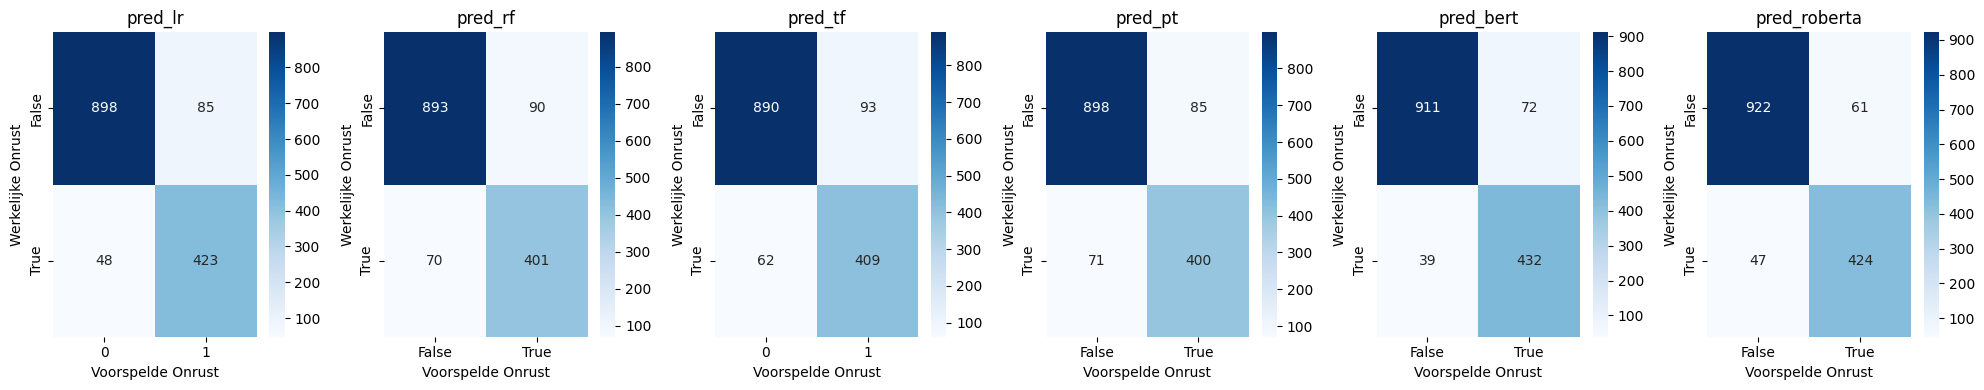

In [58]:
def plot_kruistabel(data, model_name, subplot):
    kruistabel = pd.crosstab(data['onrust'], data[model_name], 
                             rownames=['Werkelijke Onrust'], colnames=['Voorspelde Onrust'])
    sns.heatmap(kruistabel, annot=True, fmt='d', cmap='Blues', ax=subplot)
    subplot.set_title(model_name)

# Maak een figuur en definieer subplots
fig, axs = plt.subplots(1, 6, figsize=(20, 4))  # 5 modellen naast elkaar

# Plot elke kruistabel in zijn eigen subplot
plot_kruistabel(df_valid_pred, 'pred_lr', axs[0])
plot_kruistabel(df_valid_pred, 'pred_rf', axs[1])
plot_kruistabel(df_valid_pred, 'pred_tf', axs[2])
plot_kruistabel(df_valid_pred, 'pred_pt', axs[3])
plot_kruistabel(df_valid_pred, 'pred_bert', axs[4])
plot_kruistabel(df_valid_pred, 'pred_roberta', axs[5])

plt.tight_layout()
plt.show()

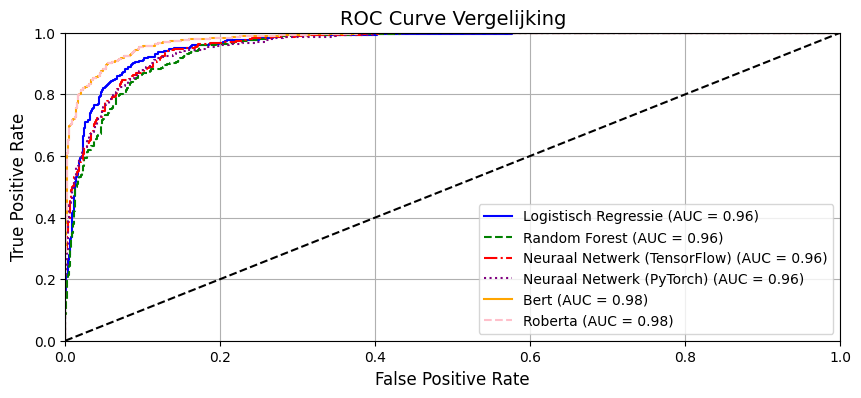

In [59]:
# Bereken de ROC-curve
fpr_lr, tpr_lr, thresholds_lr = roc_curve(df_valid_pred['onrust'], df_valid_pred['pred_lr_prob'])
fpr_rf, tpr_rf, thresholds_rf = roc_curve(df_valid_pred['onrust'], df_valid_pred['pred_rf_prob'])
fpr_tf, tpr_tf, thresholds_tf = roc_curve(df_valid_pred['onrust'], df_valid_pred['pred_tf_prob'])
fpr_pt, tpr_pt, thresholds_pt = roc_curve(df_valid_pred['onrust'], df_valid_pred['pred_pt_prob'])
fpr_bert, tpr_bert, thresholds_bert = roc_curve(df_valid_pred['onrust'], df_valid_pred['pred_bert_prob'])
fpr_roberta, tpr_roberta, thresholds_roberta = roc_curve(df_valid_pred['onrust'], df_valid_pred['pred_roberta_prob'])

# Bereken de AUC (Area Under Curve)
roc_auc_lr = roc_auc_score(df_valid_pred['onrust'], df_valid_pred['pred_lr_prob'])
roc_auc_rf = roc_auc_score(df_valid_pred['onrust'], df_valid_pred['pred_rf_prob'])
roc_auc_tf = roc_auc_score(df_valid_pred['onrust'], df_valid_pred['pred_tf_prob'])
roc_auc_pt = roc_auc_score(df_valid_pred['onrust'], df_valid_pred['pred_pt_prob'])
roc_auc_bert = roc_auc_score(df_valid_pred['onrust'], df_valid_pred['pred_bert_prob'])
roc_auc_roberta = roc_auc_score(df_valid_pred['onrust'], df_valid_pred['pred_roberta_prob'])

plt.figure(figsize=(10, 4))

# ROC Curves
plt.plot(fpr_lr, tpr_lr, label='Logistisch Regressie (AUC = {:.2f})'.format(roc_auc_lr), color='blue', linestyle='-')
plt.plot(fpr_rf, tpr_rf, label='Random Forest (AUC = {:.2f})'.format(roc_auc_rf), color='green', linestyle='--')
plt.plot(fpr_tf, tpr_tf, label='Neuraal Netwerk (TensorFlow) (AUC = {:.2f})'.format(roc_auc_tf), color='red', linestyle='-.')
plt.plot(fpr_pt, tpr_pt, label='Neuraal Netwerk (PyTorch) (AUC = {:.2f})'.format(roc_auc_pt), color='purple', linestyle=':')
plt.plot(fpr_bert, tpr_bert, label='Bert (AUC = {:.2f})'.format(roc_auc_bert), color='orange', linestyle='-')
plt.plot(fpr_bert, tpr_bert, label='Roberta (AUC = {:.2f})'.format(roc_auc_roberta), color='pink', linestyle='--')

# Baseline
plt.plot([0, 1], [0, 1], 'k--')

# Assen en Titel
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve Vergelijking', fontsize=14)

# Legenda
plt.legend(loc='lower right', fontsize=10)

# Grid
plt.grid(True)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])

plt.show()

In [60]:
# Precict on custom text
custom_text = "Hij heeft me geslagen"

# Tokenize the text
inputs = bc_tokenizer(custom_text, padding=True, truncation=True, max_length=512, return_tensors="pt")

# Predict
bc_model.eval()
with torch.no_grad():
    outputs = bc_model(**inputs)
    logits = outputs.logits

# Convert logits to probabilities
probabilities = torch.nn.functional.softmax(logits, dim=1)

# Extract the highest probability and its corresponding label
predicted_prob, predicted_label = torch.max(probabilities, dim=1)
predicted_prob = predicted_prob.item() # Convert to a Python number
predicted_label = predicted_label.item() # Convert to a Python number

print(f"Predicted Label: {predicted_label}, Predicted Probability: {predicted_prob}")


Predicted Label: 1, Predicted Probability: 0.870868980884552


In [62]:
def evaluate_model_performance(actuals, predictions, model_name="Model"):
    """
    Evaluates the performance of a binary classification model including specificity.

    Parameters:
    actuals (array-like): The actual labels.
    predictions (array-like): The predicted labels.
    model_name (str): Name of the model for display purposes.

    Returns:
    None: Prints the performance metrics.
    """
    # Calculate the confusion matrix
    cm = confusion_matrix(actuals, predictions)

    # Calculate the metrics
    accuracy = accuracy_score(actuals, predictions)
    precision = precision_score(actuals, predictions)
    recall = recall_score(actuals, predictions)
    f1 = f1_score(actuals, predictions)
    specificity = calculate_specificity(actuals, predictions)

    model_name = model_name.ljust(20)

    # Print the results
    print(f"{model_name} - Accuracy: {accuracy:.2f}, Precision: {precision:.2f}, Recall/Sensitivity: {recall:.2f}, Specificity: {specificity:.2f}, F1 Score: {f1:.2f}")

In [63]:
evaluate_model_performance(df_valid_pred['onrust'], df_valid_pred['pred_lr'], 'Logistic regression')
evaluate_model_performance(df_valid_pred['onrust'], df_valid_pred['pred_rf'], 'Random Forest')
evaluate_model_performance(df_valid_pred['onrust'], df_valid_pred['pred_tf'], 'TensorFlow')
evaluate_model_performance(df_valid_pred['onrust'], df_valid_pred['pred_pt'], 'PyTorch')
evaluate_model_performance(df_valid_pred['onrust'], df_valid_pred['pred_bert'], 'Bert llm')
evaluate_model_performance(df_valid_pred['onrust'], df_valid_pred['pred_roberta'], 'Roberta llm')

Logistic regression  - Accuracy: 0.91, Precision: 0.83, Recall/Sensitivity: 0.90, Specificity: 0.91, F1 Score: 0.86
Random Forest        - Accuracy: 0.89, Precision: 0.82, Recall/Sensitivity: 0.85, Specificity: 0.91, F1 Score: 0.83
TensorFlow           - Accuracy: 0.89, Precision: 0.81, Recall/Sensitivity: 0.87, Specificity: 0.91, F1 Score: 0.84
PyTorch              - Accuracy: 0.89, Precision: 0.82, Recall/Sensitivity: 0.85, Specificity: 0.91, F1 Score: 0.84
Bert llm             - Accuracy: 0.92, Precision: 0.86, Recall/Sensitivity: 0.92, Specificity: 0.93, F1 Score: 0.89
Roberta llm          - Accuracy: 0.93, Precision: 0.87, Recall/Sensitivity: 0.90, Specificity: 0.94, F1 Score: 0.89
